# 6D-VHQ Analysis Notebook 3: Multi-questionnaire Validation Analysis with Experiment 3

## File Setup

In [1]:
## libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
from statsmodels.stats.multitest import multipletests



In [ ]:
### filepaths ###

project_path =  Path().resolve().parent 
tables_path = os.path.join(project_path, "tables_data")
qKeys_path = os.path.join(project_path, "question_keys")


## Import data from experiment 3 across questionnaires

In [3]:
### import data tables

df_vhq_rec_dims = pd.read_csv(os.path.join(tables_path, "df_vhq_rec_dims.csv"))
display(df_vhq_rec_dims)

df_background_rec = pd.read_csv(os.path.join(tables_path, "df_background_rec.csv")) 
display(df_background_rec)

df_asc_rec_dims = pd.read_csv(os.path.join(tables_path, "df_asc_rec_dims.csv"))
display(df_asc_rec_dims)

df_mbq_rec_dims = pd.read_csv(os.path.join(tables_path, "df_mbq_rec_dims.csv"))
display(df_mbq_rec_dims)

df_psiq_rec_dims = pd.read_csv(os.path.join(tables_path, "df_psiq_rec_dims.csv"))
display(df_psiq_rec_dims)

,ResponseId,geometric,semantic,detail,vividness,entropy,focality
0,R_2XhSm3rVuTDh2XT,1.333333,5.000000,5.000000,4.333333,1.666667,2.666667
1,R_82J66rTAKMAkEMO,1.666667,2.000000,3.333333,5.000000,1.666667,1.333333
2,R_80OjC1M5y1RxlPM,5.000000,4.333333,2.000000,4.333333,1.666667,3.000000
3,R_8rdBxiZHeShoPvf,5.000000,1.333333,3.333333,3.333333,3.000000,4.000000
4,R_2rH7YSrGIo4VOqn,5.000000,3.666667,5.000000,5.000000,2.333333,3.000000
...,...,...,...,...,...,...,...
196,R_7cTzDfiLPQ0wBC9,5.000000,2.333333,5.000000,5.000000,1.000000,1.000000
197,R_1levP6TzI6EFeP7,3.666667,3.666667,4.000000,4.333333,4.333333,1.333333
198,R_6QEuAAP3YqW0Th7,3.666667,2.666667,4.333333,4.000000,1.000000,2.666667
199,R_6rF4jrVpI9mVj9v,3.000000,3.000000,5.000000,5.000000,1.000000,3.666667


,ResponseId,substance_codes,substance_labels,primary_substance_code,primary_substance,dosage_code,dosage_label,dosage_text,other_substances_any,other_substances_text,stage_code,stage_label,when_code,when_label
0,R_2XhSm3rVuTDh2XT,[2],Psilocybin,2.0,Psilocybin,5.0,very high,7g,False,NaN,4,late middle,2,within the past month
1,R_82J66rTAKMAkEMO,[2],Psilocybin,2.0,Psilocybin,NaN,Not reported,2.5gms psychedelic mushrooms,False,NaN,2,early middle,1,within the past week
2,R_80OjC1M5y1RxlPM,[3],Ayahuasca,3.0,Ayahuasca,4.0,high,NaN,False,NaN,3,middle,3,within the past 3 months
3,R_8rdBxiZHeShoPvf,[2],Psilocybin,2.0,Psilocybin,3.0,moderate,1 and a half grams of magic mushrooms,True,NaN,5,end,4,within the past 6 months
4,R_2rH7YSrGIo4VOqn,[2],Psilocybin,2.0,Psilocybin,2.0,small,0.5 grams,False,NaN,1,beginning,1,within the past week
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,R_7cTzDfiLPQ0wBC9,[6],5-MeO-DMT,6.0,5-MeO-DMT,3.0,moderate,Roughly .02mg,False,NaN,3,middle,1,within the past week
197,R_1levP6TzI6EFeP7,[1],LSD,1.0,LSD,4.0,high,200,True,NaN,3,middle,1,within the past week
198,R_6QEuAAP3YqW0Th7,[2],Psilocybin,2.0,Psilocybin,3.0,moderate,4 grams,False,NaN,1,beginning,1,within the past week
199,R_6rF4jrVpI9mVj9v,[2],Psilocybin,2.0,Psilocybin,3.0,moderate,4 grams,False,NaN,1,beginning,1,within the past week


,ResponseId,experience_of_unity,spiritual_experience,blissful_state,insightfulness,disembodiment,impaired_control_and_cognition,anxiety,complex_imagery,elementary_imagery,audio_visual_synesthesia,changed_meaning_of_percepts
0,R_2XhSm3rVuTDh2XT,56.6,30.666667,80.666667,51.000000,2.333333,6.125,22.2,68.333333,2.333333,13.666667,32.333333
1,R_82J66rTAKMAkEMO,19.8,22.666667,19.666667,41.666667,11.000000,11.000,23.2,42.333333,14.666667,22.000000,21.000000
2,R_80OjC1M5y1RxlPM,90.8,72.666667,81.000000,88.333333,100.000000,28.875,33.4,59.333333,63.666667,85.000000,95.333333
3,R_8rdBxiZHeShoPvf,10.2,4.000000,43.666667,36.666667,36.000000,3.875,5.4,47.666667,28.000000,5.666667,10.333333
4,R_2rH7YSrGIo4VOqn,25.2,46.666667,77.000000,39.000000,8.666667,17.750,16.4,55.666667,69.666667,100.000000,23.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
196,R_7cTzDfiLPQ0wBC9,98.0,66.000000,99.000000,65.333333,99.333333,6.375,20.8,24.333333,33.000000,15.000000,45.333333
197,R_1levP6TzI6EFeP7,30.6,33.333333,47.666667,38.000000,21.333333,18.875,18.8,66.666667,66.666667,100.000000,8.333333
198,R_6QEuAAP3YqW0Th7,28.4,29.666667,44.333333,20.000000,16.000000,16.750,28.8,34.666667,33.000000,78.333333,23.000000
199,R_6rF4jrVpI9mVj9v,25.6,48.000000,44.333333,27.000000,7.000000,7.375,17.4,34.333333,30.333333,90.666667,9.666667


,ResponseId,Non-Physicalist Beliefs
0,R_2XhSm3rVuTDh2XT,5.777778
1,R_82J66rTAKMAkEMO,5.555556
2,R_80OjC1M5y1RxlPM,6.666667
3,R_8rdBxiZHeShoPvf,4.666667
4,R_2rH7YSrGIo4VOqn,6.222222
...,...,...
196,R_7cTzDfiLPQ0wBC9,5.555556
197,R_1levP6TzI6EFeP7,4.333333
198,R_6QEuAAP3YqW0Th7,6.444444
199,R_6rF4jrVpI9mVj9v,6.555556


,ResponseId,vision,sound,smell,taste,touch,bodily,emotional
0,R_2XhSm3rVuTDh2XT,10.000000,10.0,10.0,10.0,10.0,10.00,10.0
1,R_82J66rTAKMAkEMO,8.666667,7.0,8.0,8.5,8.5,7.40,7.4
2,R_80OjC1M5y1RxlPM,7.800000,6.0,4.8,7.6,7.6,7.00,4.2
3,R_8rdBxiZHeShoPvf,10.000000,9.6,9.6,10.0,10.0,9.20,7.2
4,R_2rH7YSrGIo4VOqn,0.000000,0.0,0.0,0.0,0.0,0.00,1.6
...,...,...,...,...,...,...,...,...
196,R_7cTzDfiLPQ0wBC9,8.000000,8.0,8.0,8.0,7.6,8.00,8.0
197,R_1levP6TzI6EFeP7,8.200000,9.2,8.4,9.2,9.6,9.75,10.0
198,R_6QEuAAP3YqW0Th7,7.000000,5.4,7.2,5.2,8.6,8.60,8.2
199,R_6rF4jrVpI9mVj9v,7.200000,7.6,6.4,5.2,7.8,8.20,8.2


In [4]:
### create lists of dimension names

vhq_dimension_columns = df_vhq_rec_dims.columns.tolist()
asc_dimension_columns = df_asc_rec_dims.columns.tolist()

vhq_dimension_columns.remove("ResponseId")
asc_dimension_columns.remove("ResponseId")

print("VHQ dimension columns:", vhq_dimension_columns)
print("ASC dimension columns:", asc_dimension_columns)

# --- VHQ: rename first two items ---
vhq_dimensions = vhq_dimension_columns.copy()
vhq_dimensions[0] = "geometric content"
vhq_dimensions[1] = "semantic content"

# --- ASC: replace underscores with spaces ---
asc_dimensions = [c.replace("_", " ") for c in asc_dimension_columns]


print("VHQ dimensions:", vhq_dimensions)
print("ASC dimensions:", asc_dimensions)

VHQ dimension columns: ['geometric', 'semantic', 'detail', 'vividness', 'entropy', 'focality']
ASC dimension columns: ['experience_of_unity', 'spiritual_experience', 'blissful_state', 'insightfulness', 'disembodiment', 'impaired_control_and_cognition', 'anxiety', 'complex_imagery', 'elementary_imagery', 'audio_visual_synesthesia', 'changed_meaning_of_percepts']
VHQ dimensions: ['geometric content', 'semantic content', 'detail', 'vividness', 'entropy', 'focality']
ASC dimensions: ['experience of unity', 'spiritual experience', 'blissful state', 'insightfulness', 'disembodiment', 'impaired control and cognition', 'anxiety', 'complex imagery', 'elementary imagery', 'audio visual synesthesia', 'changed meaning of percepts']


## Shared dimension Correspondance

Do the dimensions shared between the 6D-VHQ and 11D-ASC correlate to one another


=== Geometric/simple hallucinations ===
Predictor (X): geometric content (VHQ)
Outcome  (Y): elementary imagery (ASC)
Pearson r = 0.409, p_raw = 1.735e-09, p_holm = 1.735e-09
Linear model: Y ~ X
  Intercept (b0) = 21.661
  Slope     (b1) = 7.173
  R² = 0.167, p_holm (slope) = 1.735e-09


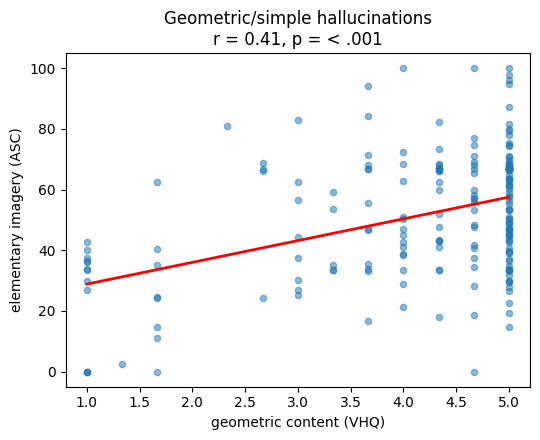


=== Semantic/complex hallucinations ===
Predictor (X): semantic content (VHQ)
Outcome  (Y): complex imagery (ASC)
Pearson r = 0.420, p_raw = 5.169e-10, p_holm = 1.034e-09
Linear model: Y ~ X
  Intercept (b0) = 31.044
  Slope     (b1) = 9.214
  R² = 0.177, p_holm (slope) = 1.034e-09


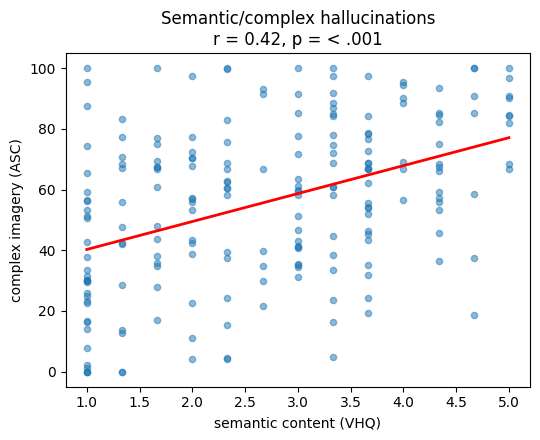


Supplementary table: VHQ–ASC dimension correlations (Holm-corrected across 2 tests)
                              desc            x_label             y_label  \
0  Geometric/simple hallucinations  geometric content  elementary imagery   
1  Semantic/complex hallucinations   semantic content     complex imagery   

     n      r  p_raw  p_holm  
0  201  0.409    0.0     0.0  
1  201  0.420    0.0     0.0  


,desc,x_label,y_label,n,r,p_raw,p_holm
0,Geometric/simple hallucinations,geometric content,elementary imagery,201,0.408550,1.734611e-09,1.734611e-09
1,Semantic/complex hallucinations,semantic content,complex imagery,201,0.420433,5.168791e-10,1.033758e-09


In [5]:
# ============================================================
# 1. Merge VHQ and ASC scores (one row per experience)
# ============================================================

df_va = df_vhq_rec_dims.merge(df_asc_rec_dims, on="ResponseId", how="inner")

# ------------------------------------------------------------
# 2. Identify the relevant columns by index
# ------------------------------------------------------------

vhq_geom_col = vhq_dimension_columns[0]
asc_geom_col = asc_dimension_columns[8]

vhq_sem_col  = vhq_dimension_columns[1]
asc_sem_col  = asc_dimension_columns[7]

vhq_geom_label = vhq_dimensions[0]
asc_geom_label = asc_dimensions[8]

vhq_sem_label  = vhq_dimensions[1]
asc_sem_label  = asc_dimensions[7]

pairs = [
    (vhq_geom_col, asc_geom_col, vhq_geom_label, asc_geom_label, "Geometric/simple hallucinations"),
    (vhq_sem_col,  asc_sem_col,  vhq_sem_label,  asc_sem_label,  "Semantic/complex hallucinations"),
]

# ============================================================
# 3. First pass: compute correlations and store results
# ============================================================

results = []
p_raw_list = []

for x_col, y_col, x_label, y_label, desc in pairs:
    df_pair = df_va[[x_col, y_col]].dropna().copy()
    x = df_pair[x_col].values
    y = df_pair[y_col].values

    r, p_r = stats.pearsonr(x, y)

    results.append({
        "desc": desc,
        "x_col": x_col,
        "y_col": y_col,
        "x_label": x_label,
        "y_label": y_label,
        "r": r,
        "p_raw": p_r,
        "n": len(df_pair)
    })
    p_raw_list.append(p_r)

# ============================================================
# 4. Holm–Bonferroni correction across the two correlations
# ============================================================

p_adj = multipletests(p_raw_list, alpha=0.05, method="holm")[1]
for res, p_a in zip(results, p_adj):
    res["p_holm"] = p_a

# ============================================================
# 5. Second pass: reporting + plotting using adjusted p
# ============================================================

for res in results:
    x_col = res["x_col"]
    y_col = res["y_col"]
    x_label = res["x_label"]
    y_label = res["y_label"]
    desc = res["desc"]
    r = res["r"]
    p_raw = res["p_raw"]
    p_adj = res["p_holm"]

    df_pair = df_va[[x_col, y_col]].dropna().copy()
    x = df_pair[x_col].values
    y = df_pair[y_col].values

    # Linear model
    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()

    print(f"\n=== {desc} ===")
    print(f"Predictor (X): {x_label} (VHQ)")
    print(f"Outcome  (Y): {y_label} (ASC)")
    print(f"Pearson r = {r:.3f}, p_raw = {p_raw:.4g}, p_holm = {p_adj:.4g}")
    print(f"Linear model: Y ~ X")
    print(f"  Intercept (b0) = {model.params[0]:.3f}")
    print(f"  Slope     (b1) = {model.params[1]:.3f}")
    print(f"  R² = {model.rsquared:.3f}, p_holm (slope) = {p_adj:.4g}")

    # Scatter + regression line
    x_grid = np.linspace(x.min(), x.max(), 100)
    y_pred = model.predict(sm.add_constant(x_grid))

    plt.figure(figsize=(5.5, 4.5))
    plt.scatter(x, y, alpha=0.5, s=20)
    plt.plot(x_grid, y_pred, color="red", linewidth=2)

    plt.xlabel(f"{x_label} (VHQ)")
    plt.ylabel(f"{y_label} (ASC)")
    plt.title(
        f"{desc}\n"
        f"r = {r:.2f}, p = {'< .001' if p_adj < 0.001 else f'{p_adj:.3f}'.replace('0.', '.')}"
    )

    plt.tight_layout()
    plt.show()

# ============================================================
# 6. Supplementary table
# ============================================================

supp_table = pd.DataFrame(results)
supp_table = supp_table[
    ["desc", "x_label", "y_label", "n", "r", "p_raw", "p_holm"]
]

print("\nSupplementary table: VHQ–ASC dimension correlations (Holm-corrected across 2 tests)")
print(supp_table.round(3))

supp_table

### Do beliefs and imagery influence responses


=== asc_mean ~ mbq ===
β = 3.691, t = 4.44, p_raw = 1.52e-05, p_holm = 3.04e-05, R² = 0.090, n = 201

=== vhq_mean ~ mbq ===
β = 0.012, t = 0.47, p_raw = 0.6354, p_holm = 0.6354, R² = 0.001, n = 201

=== asc_mean ~ psiq_vision ===
β = 1.270, t = 2.80, p_raw = 0.005602, p_holm = 0.0112, R² = 0.038, n = 201

=== vhq_mean ~ psiq_vision ===
β = 0.018, t = 1.34, p_raw = 0.1806, p_holm = 0.1806, R² = 0.009, n = 201


C:\Users\Trevor\AppData\Local\Temp\ipykernel_5928\4062248863.py:50: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "beta": model.params[1],
C:\Users\Trevor\AppData\Local\Temp\ipykernel_5928\4062248863.py:51: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "t": model.tvalues[1],
C:\Users\Trevor\AppData\Local\Temp\ipykernel_5928\4062248863.py:52: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "p_raw": model.pvalues[1],
C:\Users\Trevor\App

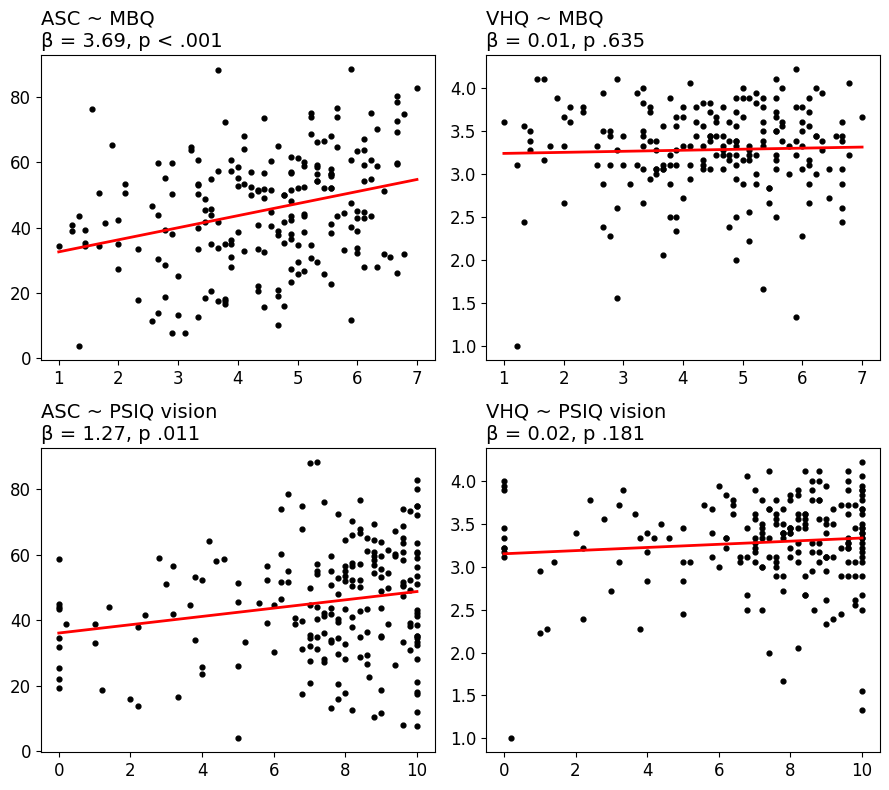


Supplementary table: Trait predictors of questionnaire responses
  family   outcome    predictor    n   beta      t     r2  p_raw  p_holm
0    MBQ  asc_mean          mbq  201  3.691  4.435  0.090  0.000   0.000
1    MBQ  vhq_mean          mbq  201  0.012  0.475  0.001  0.635   0.635
2   PSIQ  asc_mean  psiq_vision  201  1.270  2.801  0.038  0.006   0.011
3   PSIQ  vhq_mean  psiq_vision  201  0.018  1.344  0.009  0.181   0.181


,family,outcome,predictor,n,beta,t,r2,p_raw,p_holm
0,MBQ,asc_mean,mbq,201,3.691,4.435,0.090,0.000,0.000
1,MBQ,vhq_mean,mbq,201,0.012,0.475,0.001,0.635,0.635
2,PSIQ,asc_mean,psiq_vision,201,1.270,2.801,0.038,0.006,0.011
3,PSIQ,vhq_mean,psiq_vision,201,0.018,1.344,0.009,0.181,0.181


In [ ]:
# ----------------------------
# Construct df_overall_rec_dims
# ----------------------------

vhq_dims = ['geometric','semantic','detail','vividness','entropy','focality']
asc_dims = [
    'experience_of_unity','spiritual_experience','blissful_state','insightfulness',
    'disembodiment','impaired_control_and_cognition','anxiety',
    'complex_imagery','elementary_imagery','audio_visual_synesthesia',
    'changed_meaning_of_percepts'
]

mbq_dim = 'Non-Physicalist Beliefs'
psiq_vision_dim = 'vision'

df_overall_rec_dims = pd.DataFrame({
    "ResponseId": df_vhq_rec_dims["ResponseId"].values,
    "vhq_mean": df_vhq_rec_dims[vhq_dims].mean(axis=1).values,
    "asc_mean": df_asc_rec_dims[asc_dims].mean(axis=1).values,
    "mbq": df_mbq_rec_dims[mbq_dim].values,
    "psiq_vision": df_psiq_rec_dims[psiq_vision_dim].values
})

# ----------------------------
# Linear models (first pass)
# ----------------------------

def fit_model(y_var, x_var):
    y = df_overall_rec_dims[y_var]
    X = sm.add_constant(df_overall_rec_dims[x_var])
    model = sm.OLS(y, X).fit()
    return model

models_info = [
    {"y": "asc_mean", "x": "mbq", "family": "MBQ"},
    {"y": "vhq_mean", "x": "mbq", "family": "MBQ"},
    {"y": "asc_mean", "x": "psiq_vision", "family": "PSIQ"},
    {"y": "vhq_mean", "x": "psiq_vision", "family": "PSIQ"},
]

results = []

for info in models_info:
    model = fit_model(info["y"], info["x"])
    results.append({
        "family": info["family"],
        "outcome": info["y"],
        "predictor": info["x"],
        "model": model,
        "beta": model.params[1],
        "t": model.tvalues[1],
        "p_raw": model.pvalues[1],
        "r2": model.rsquared,
        "n": int(model.nobs)
    })

results_df = pd.DataFrame(results)

# ----------------------------
# Holm correction within each family (2 tests each)
# ----------------------------

results_df["p_holm"] = np.nan

for fam, idx in results_df.groupby("family").groups.items():
    pvals = results_df.loc[idx, "p_raw"].values
    p_adj = multipletests(pvals, alpha=0.05, method="holm")[1]
    results_df.loc[idx, "p_holm"] = p_adj

# ----------------------------
# Reporting 
# ----------------------------

for _, row in results_df.iterrows():
    print(f"\n=== {row['outcome']} ~ {row['predictor']} ===")
    print(f"β = {row['beta']:.3f}, t = {row['t']:.2f}, "
          f"p_raw = {row['p_raw']:.4g}, p_holm = {row['p_holm']:.4g}, "
          f"R² = {row['r2']:.3f}, n = {row['n']}")

# ----------------------------
# Compact 2×2 plotting 
# ----------------------------

fig, axes = plt.subplots(2, 2, figsize=(9, 8))
axes = axes.flatten()

titles = [
    "ASC ~ MBQ",
    "VHQ ~ MBQ",
    "ASC ~ PSIQ vision",
    "VHQ ~ PSIQ vision"
]

for ax, (_, row), title in zip(axes, results_df.iterrows(), titles):
    model = row["model"]
    y = model.model.endog
    x = model.model.exog[:, 1]

    ax.scatter(x, y, s=12, color="black")
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = model.params[0] + model.params[1] * x_line
    ax.plot(x_line, y_line, color="red", linewidth=2)

    p_adj = row["p_holm"]
    p_txt = "< .001" if p_adj < 0.001 else f"{p_adj:.3f}".replace("0.", ".")

    ax.set_title(f"{title}\nβ = {row['beta']:.2f}, p {p_txt}", fontsize=14, loc="left")
    ax.tick_params(axis='both', labelsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

# ----------------------------
# Supplementary table
# ----------------------------

supp_table = results_df[[
    "family", "outcome", "predictor", "n",
    "beta", "t", "r2", "p_raw", "p_holm"
]].round(3)

print("\nSupplementary table: Trait predictors of questionnaire responses")
print(supp_table)

supp_table

C:\Users\Trevor\AppData\Local\Temp\ipykernel_5928\2486701041.py:59: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  b0, b1 = model.params["const"], model.params[model.params.index != "const"][0]
C:\Users\Trevor\AppData\Local\Temp\ipykernel_5928\2486701041.py:82: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p = model.pvalues[1]
C:\Users\Trevor\AppData\Local\Temp\ipykernel_5928\2486701041.py:59: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[po

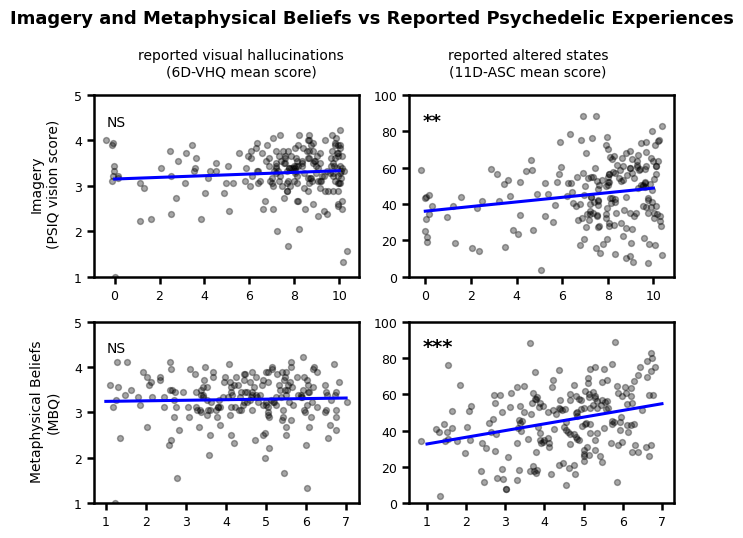

In [ ]:

# Refined visualisation block (run after models m1–m4, df_overall_rec_dims)

fig, axes = plt.subplots(2, 2, figsize=(7, 6))
axes = axes.reshape(2, 2)

# Mapping models and data to positions:
# Top row: Imagery (PSIQ vision)
#   [0,0] VHQ ~ PSIQ vision  -> m4
#   [0,1] ASC ~ PSIQ vision  -> m2
# Bottom row: Metaphysical Beliefs (MBQ)
#   [1,0] VHQ ~ MBQ          -> m3
#   [1,1] ASC ~ MBQ          -> m1

X_mbq  = sm.add_constant(df_overall_rec_dims["mbq"])
X_psiq = sm.add_constant(df_overall_rec_dims["psiq_vision"])

m1 = sm.OLS(df_overall_rec_dims["asc_mean"], X_mbq).fit()
m2 = sm.OLS(df_overall_rec_dims["asc_mean"], X_psiq).fit()
m3 = sm.OLS(df_overall_rec_dims["vhq_mean"], X_mbq).fit()
m4 = sm.OLS(df_overall_rec_dims["vhq_mean"], X_psiq).fit()

configs = [
    {"ax": axes[0, 0], "model": m4, "x": df_overall_rec_dims["psiq_vision"], "y": df_overall_rec_dims["vhq_mean"], "y_type": "vhq"},
    {"ax": axes[0, 1], "model": m2, "x": df_overall_rec_dims["psiq_vision"], "y": df_overall_rec_dims["asc_mean"],  "y_type": "asc"},
    {"ax": axes[1, 0], "model": m3, "x": df_overall_rec_dims["mbq"],         "y": df_overall_rec_dims["vhq_mean"], "y_type": "vhq"},
    {"ax": axes[1, 1], "model": m1, "x": df_overall_rec_dims["mbq"],         "y": df_overall_rec_dims["asc_mean"], "y_type": "asc"},
]

rng = np.random.default_rng(42)

def p_to_stars_and_style(p):
    if p < 0.001:
        return "***", 14, "bold"
    elif p < 0.01:
        return "**", 13, "bold"
    elif p < 0.05:
        return "*", 12, "bold"
    else:
        return "NS", 10, "normal"

for cfg in configs:
    ax    = cfg["ax"]
    model = cfg["model"]
    x     = cfg["x"].values
    y     = cfg["y"].values

    # Jitter (x only)
    x_range = x.max() - x.min()
    if x_range > 0:
        jitter = rng.normal(0, 0.02 * x_range, size=len(x))
        x_jit = x + jitter
    else:
        x_jit = x

    # Scatter
    ax.scatter(x_jit, y, s=18, alpha=0.35, color="black")

    # Regression line from model 
    b0, b1 = model.params["const"], model.params[model.params.index != "const"][0]
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = b0 + b1 * x_line
    ax.plot(x_line, y_line, linestyle="-", color="blue", linewidth=2.2, zorder=3)

    # Y axis limits and ticks
    if cfg["y_type"] == "vhq":
        ax.set_ylim(1, 5)
        ax.set_yticks(np.arange(1, 6, 1))
    else:  # asc
        ax.set_ylim(0, 100)
        ax.set_yticks(np.arange(0, 101, 20))

    # Thicker axes and ticks
    for spine in ax.spines.values():
        spine.set_linewidth(1.8)
    ax.tick_params(axis='both', width=1.8, length=5, labelsize=9)

    # No axis labels (column/row labels handled at figure level)
    ax.set_xlabel("")
    ax.set_ylabel("")

    # Significance label from slope p-value
    p = model.pvalues[1]
    label, fs, weight = p_to_stars_and_style(p)
    ax.text(0.05, 0.83, label, transform=ax.transAxes,
            fontsize=fs, fontweight=weight)

# Wrapped, left-aligned title (two lines)
fig.text(
    0.01, 0.97,
    "Imagery and Metaphysical Beliefs vs Reported Psychedelic Experiences",
    ha="left", va="top", fontsize=13, fontweight="bold"
)

# Column labels (VHQ left, ASC right) – moved slightly down to reduce gap
fig.text(0.34, 0.88,
         "reported visual hallucinations\n(6D-VHQ mean score)",
         ha="center", va="center", fontsize=10)
fig.text(0.75, 0.88,
         "reported altered states\n(11D-ASC mean score)",
         ha="center", va="center", fontsize=10)

# Row labels (Imagery / Metaphysical Beliefs)
fig.text(0.06, 0.68,
         "Imagery\n(PSIQ vision score)",
         ha="center", va="center", fontsize=10, rotation=90)
fig.text(0.06, 0.3,
         "Metaphysical Beliefs\n(MBQ)",
         ha="center", va="center", fontsize=10, rotation=90)

plt.tight_layout(rect=[0.08, 0.08, 0.98, 0.86])
plt.show()
